# Create graphs showing the relationship between CV and RLD

In [10]:
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import LogLocator, ScalarFormatter
from scipy.stats import lognorm

BASE_DIR = Path.cwd()

### Helper functions:

In [11]:
# transform to perirhizal radius PDF (analytically)
def pdf_perirhizal_mm(r_mm: np.ndarray, mu_ln: float, sigma_ln: float) -> np.ndarray:
    """Closed-form PDF for radius in mm induced by a lognormal RLD.

    Assumptions:
        - X = RLD is lognormal with ln(X) ~ N(mu_ln, sigma_ln^2)
        - Radius mapping: r_mm = 10 * sqrt(1 / (pi * X))

    Then r_mm is also lognormal with
        ln(r_mm) ~ N(mu_r, sigma_r^2)
        mu_r    = ln(10) - 0.5*ln(pi) - 0.5*mu_ln
        sigma_r = 0.5*sigma_ln
    """
    mu_r = np.log(10.0) - 0.5 * np.log(np.pi) - 0.5 * mu_ln
    sigma_r = 0.5 * sigma_ln
    return lognorm.pdf(r_mm, s=sigma_r, scale=np.exp(mu_r))

Helper functions for the plotting of the CV-RLD relationship

In [12]:
SD_BAND_MULTIPLIER = 1.0  # 1.0 means fitted CV +/- 1 residual standard deviation


def fit_log10_regression_with_sd_band(x, y, sd_multiplier=SD_BAND_MULTIPLIER):
    """Fit CV = a * log10(RLD) + b and store residual SD for the shaded band."""
    # Convert inputs to numpy arrays so filtering/math works consistently.
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Keep only usable points. RLD must be positive because log10(0) is undefined.
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[mask]
    y = y[mask]

    if x.size < 3:
        raise ValueError("Need at least 3 valid points to fit the regression and residual SD band.")

    # Fit a straight line against log10(RLD), not raw RLD.
    x_log = np.log10(x)
    coef, cov = np.polyfit(x_log, y, 1, cov=True)
    a, b = coef

    # Residuals describe how far the observed CV points are from the fitted line.
    y_fit = a * x_log + b
    residuals = y - y_fit

    # Residual SD is the typical vertical scatter around the line.
    # The shaded band later uses: fitted CV +/- sd_multiplier * residual_sd.
    dof = x.size - 2
    sse = np.sum(residuals ** 2)
    mse = sse / dof
    residual_sd = np.sqrt(mse)

    # Store everything needed for plotting/prediction later.
    return {
        "a": a,
        "b": b,
        "cov": cov,  # kept for printing/checking; not used for the SD band
        "sd_multiplier": sd_multiplier,
        "n": x.size,
        "dof": dof,
        "mse": mse,
        "residual_sd": residual_sd,
        "x_min": x.min(),
        "x_max": x.max(),
    }


def predict_log10_regression_with_sd_band(x_eval, fit, sd_multiplier=None):
    """Evaluate the fitted curve and fixed +/- residual-SD band."""
    x_eval = np.asarray(x_eval, dtype=float)
    if np.any(x_eval <= 0):
        raise ValueError("x_eval must be strictly positive for a log10 regression.")

    # Use the multiplier stored in the fit unless a different one is provided here.
    multiplier = fit["sd_multiplier"] if sd_multiplier is None else sd_multiplier

    # Predicted CV from the fitted equation: CV = a * log10(RLD) + b.
    x_log = np.log10(x_eval)
    y_pred = fit["a"] * x_log + fit["b"]

    # Fixed-width band: the same vertical +/- residual SD at every RLD value.
    delta = multiplier * fit["residual_sd"]
    return y_pred, y_pred - delta, y_pred + delta

def format_fit_equation(fit):
    a = fit["a"]
    b = fit["b"]
    return rf"$\mathrm{{CV}} = {a:.2f} \log_{{10}}(\mathrm{{RLD}}) {b:+.2f}$"

In [13]:
def plot_log10_regression_with_sd_band(
    ax,
    fit,
    x_range=None,
    line_label=None,
    line_color="tab:blue",
    line_style="-",
    line_alpha=1.0,
    line_width=2.0,
    band_label=None,
    band_color=None,
    band_alpha=0.15,
    boundary_color=None
):
    """Plot the fitted CV-RLD curve plus the fixed +/- residual-SD band."""
    # If no x-range is supplied, draw the curve over the fitted data range.
    if x_range is None:
        x_range = np.logspace(np.log10(fit["x_min"]), np.log10(fit["x_max"]), 200)

    # Get the fitted curve and its lower/upper SD-band limits.
    y_pred, y_lower, y_upper = predict_log10_regression_with_sd_band(x_range, fit)

    # By default, make the shaded band and optional boundaries match the line color.
    band_color = line_color if band_color is None else band_color
    boundary_color = line_color if boundary_color is None else boundary_color

    # Draw the fitted CV-RLD relationship.
    ax.plot(
        x_range,
        y_pred,
        color=line_color,
        linestyle=line_style,
        alpha=line_alpha,
        linewidth=line_width,
        label=line_label,
    )

    # Draw the fixed +/- residual-SD band around the fitted line.
    ax.fill_between(
        x_range,
        y_lower,
        y_upper,
        color=band_color,
        alpha=band_alpha,
        linewidth=0,
        label=band_label,
    )

    return x_range, y_pred, y_lower, y_upper


def load_field_regression_fit(sd_multiplier=SD_BAND_MULTIPLIER):
    # Measured field data from the three years.
    field_data = {
        "20.06.95": f"{BASE_DIR}/results/full_data_csv_1995.csv",
        "26.06.96": f"{BASE_DIR}/results/full_data_csv_1996.csv",
        "16.06.97": f"{BASE_DIR}/results/full_data_csv_1997.csv",
    }

    # Collect all field RLD/CV points before fitting one pooled relationship.
    all_rld = []
    all_cv = []
    for file in field_data.values():
        df = pd.read_csv(file)
        df = df[df["system"] == "soil_core"].copy()
        if "depth" in df.columns:
            df = df.sort_values("depth")

        # Measured RLD is the measured mean; measured CV is standard deviation / mean * 100.
        rld = df["measured_mean"].to_numpy(dtype=float)
        measured_std = df["measured_std"].to_numpy(dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            cv = measured_std / rld * 100
            cv[rld <= 0] = np.nan  # CV is undefined for zero or negative RLD.

        # Keep only valid positive-RLD points for the log10 regression.
        mask = np.isfinite(rld) & np.isfinite(cv) & (rld > 0)
        all_rld.append(rld[mask])
        all_cv.append(cv[mask])

    # Fit one field CV-RLD curve using all years together.
    return fit_log10_regression_with_sd_band(
        np.concatenate(all_rld),
        np.concatenate(all_cv),
        sd_multiplier=sd_multiplier,
    )


def load_simulated_regression_fit(sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007):
    # Simulated data from the three years.
    simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/full_data_csv_1995.csv",
        "26.06.96": f"{BASE_DIR}/results/full_data_csv_1996.csv",
        "16.06.97": f"{BASE_DIR}/results/full_data_csv_1997.csv",
    }

    # Collect all simulated RLD/CV points before fitting one pooled relationship.
    all_rld = []
    all_cv = []
    for file in simulated_data.values():
        df = pd.read_csv(file)

        # Use only the soil-core simulation results, then sort by depth for consistency.
        df = df[df["system"] == "soil_core"].copy()
        if "depth" in df.columns:
            df = df.sort_values("depth")

        # Simulated RLD is the simulated mean; simulated CV is std / mean * 100.
        rld = df["simulated_mean"].values
        with np.errstate(divide="ignore", invalid="ignore"):
            cv = df["simulated_std"].values / rld * 100
            cv[rld == 0] = 0

        # Keep valid positive-RLD points; optionally remove tiny-RLD outliers.
        mask = np.isfinite(rld) & np.isfinite(cv) & (rld > 0)
        if rld_min is not None:
            mask &= rld >= rld_min
        all_rld.append(rld[mask])
        all_cv.append(cv[mask])

    # Fit one simulated CV-RLD curve using all years together.
    return fit_log10_regression_with_sd_band(
        np.concatenate(all_rld),
        np.concatenate(all_cv),
        sd_multiplier=sd_multiplier,
    )


def combined_log10_x_range(*fits, num=200):
    """Create one shared log-spaced RLD range covering all fitted curves."""
    x_min = min(fit["x_min"] for fit in fits)
    x_max = max(fit["x_max"] for fit in fits)
    return np.logspace(np.log10(x_min), np.log10(x_max), num)


# Build the two fits once so both plots can reuse exactly the same curves/bands.
field_fit = load_field_regression_fit(sd_multiplier=SD_BAND_MULTIPLIER)
simulated_fit = load_simulated_regression_fit(sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_field, b_field = field_fit["a"], field_fit["b"]
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

Helper functions for the calculation of the relative standard error

In [14]:
def calculate_rse_1(mean, std, n):
    """Within-year RSE [%] from one mean/std pair."""
    # RSE_1 = ((standard deviation / mean) * 100) / sqrt(number of cores)
    if not np.isfinite(mean) or not np.isfinite(std) or mean <= 0:
        return np.nan
    return ((std / mean) * 100) / np.sqrt(n)


def clean_number(value, digits=2):
    """Convert numpy/pandas numbers to rounded Python floats for nicer printing."""
    if pd.isna(value) or not np.isfinite(value):
        return None
    return round(float(value), digits)

## Coefficient of variation

### Root length density versus coefficient of variaiton for the measured data

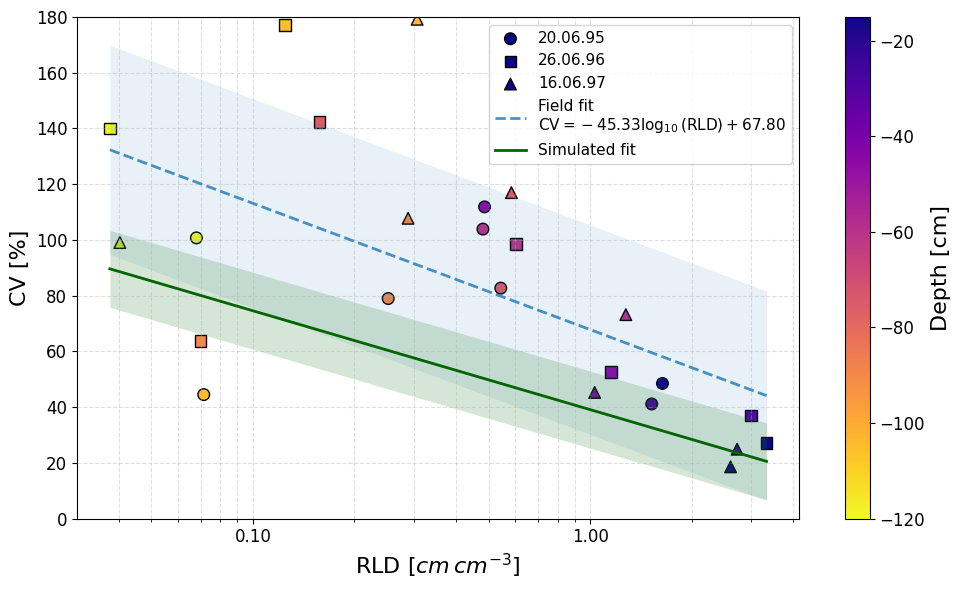

In [15]:
field_data = {
    "20.06.95": f"{BASE_DIR}/results/full_data_csv_1995.csv",  
    "26.06.96": f"{BASE_DIR}/results/full_data_csv_1996.csv",
    "16.06.97": f"{BASE_DIR}/results/full_data_csv_1997.csv",
}

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in field_data.items():

    # Load measured soil-core values from the combined results CSV
    df = pd.read_csv(file)
    df = df[df["system"] == "soil_core"].copy()
    df = df.sort_values("depth")

    depth = df["depth"].to_numpy(dtype=float)
    rld = df["measured_mean"].to_numpy(dtype=float)
    measured_std = df["measured_std"].to_numpy(dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        cv = measured_std / rld * 100   # CV [%]
        cv[rld <= 0] = np.nan

    all_points.append((label, depth, rld, cv))


fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depth, rld, cv in all_points:
    ax.scatter(
        rld, cv,
        c=-depth,
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )


# Flatten all arrays
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# shared regression fits and fixed +/- 1 residual-SD bands
x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label=f"Field fit\n{format_fit_equation(field_fit)}",
    line_style="--",
    line_alpha=0.8,
    band_alpha=0.1,
    band_label=None,
)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="Simulated fit",
    line_style="-",
    line_alpha=1.0,
    line_color="darkgreen",
    band_color="darkgreen",
    band_alpha=0.16,
    band_label=None,
)

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)
ax.grid(True, which="both", linestyle="--", alpha=0.4)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=12)
ax.legend(title="", frameon=True, fontsize=11)

plt.tight_layout()
plt.show()


### Root length density versus coefficient of variation for the simulated data

Excluding 1 point(s) with RLD < 0.007 from regression
  excluded: 26.06.96 depth=120cm  RLD=0.00124175  CV=218.23%
-35.49029721531007 39.075961056298176


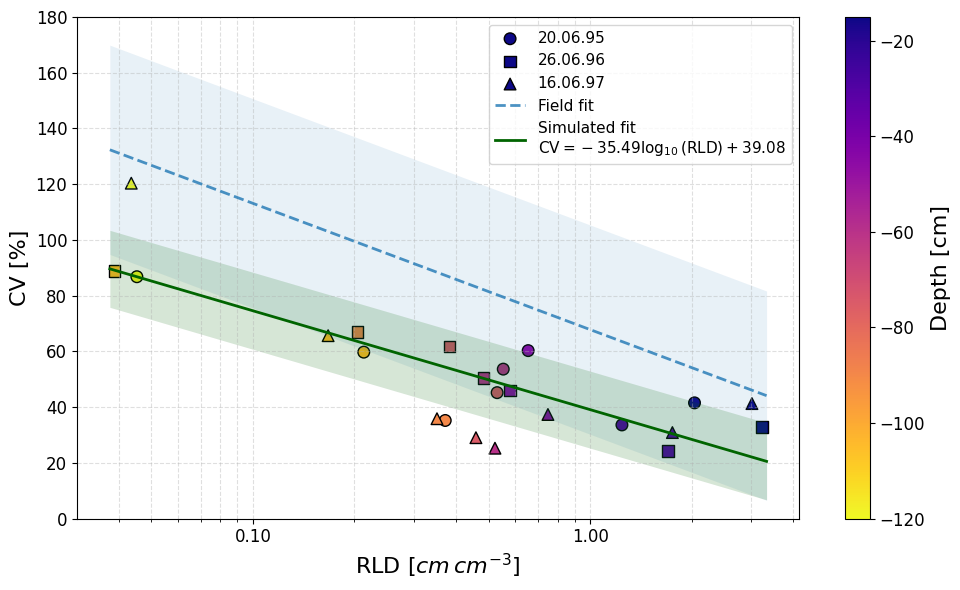

In [16]:
simulated_data = {
    "20.06.95": f"{BASE_DIR}/results/full_data_csv_1995.csv",
    "26.06.96": f"{BASE_DIR}/results/full_data_csv_1996.csv",
    "16.06.97": f"{BASE_DIR}/results/full_data_csv_1997.csv",
}

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []
manual_depths = np.array([15, 30, 45, 60, 75, 90, 105, 120])

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)
    
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    depths = manual_depths
    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )


# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")

x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="Field fit",
    line_style="--",
    line_alpha=0.8,
    band_alpha=0.1,
    band_label=None,
)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label=f"Simulated fit\n{format_fit_equation(simulated_fit)}",
    line_style="-",
    line_color="darkgreen",
    band_color="darkgreen",
    line_alpha=1.0,
    band_alpha=0.16,
    band_label=None,
)

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=12)

ax.legend(title="", frameon=True, fontsize=11)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

print(a_sim, b_sim)

plt.tight_layout()
plt.show()

## Relative standard error

In [9]:
data = {
    "20.06.95": f"{BASE_DIR}/results/full_data_csv_1995.csv",
    "26.06.96": f"{BASE_DIR}/results/full_data_csv_1996.csv",
    "16.06.97": f"{BASE_DIR}/results/full_data_csv_1997.csv",
}
n_cores = 2

rows = []
rse_1_by_year_and_depth = {}

for label, file in data.items():
    df = pd.read_csv(file)
    df = df[df["system"] == "soil_core"].copy()
    df = df.sort_values("depth")

    year = int(df["year"].dropna().iloc[0])
    rse_1_by_year_and_depth[year] = {}

    for _, row in df.iterrows():
        depth = int(row["depth"])
        mean = row["measured_mean"]
        std = row["measured_std"]
        rse_1 = calculate_rse_1(mean, std, n_cores)

        rse_1_by_year_and_depth[year][depth] = clean_number(rse_1)
        rows.append({
            "year": year,
            "depth": depth,
            "mean": mean,
            "std": std,
            "rse_1": rse_1,
        })

rse_results = {
    "rse_1_by_year_and_depth": rse_1_by_year_and_depth
}

print(f"RSE results [%] using n_cores={n_cores}:")
pprint(rse_results, sort_dicts=True)

RSE results [%] using n_cores=2:
{'rse_1_by_year_and_depth': {1995: {15: 34.28,
                                    30: 29.07,
                                    45: 79.09,
                                    60: 73.45,
                                    75: 58.47,
                                    90: 55.83,
                                    105: 31.45,
                                    120: 71.22},
                             1996: {15: 19.2,
                                    30: 26.16,
                                    45: 37.18,
                                    60: 69.74,
                                    75: 100.66,
                                    90: 44.99,
                                    105: 125.28,
                                    120: 98.96},
                             1997: {15: 13.12,
                                    30: 17.59,
                                    45: 31.99,
                                    60: 51.74,
                    